## Section A: K-Means Clustering & Elbow Method (20)
### Task 1 – K-Means & Elbow Method

- Load the Iris dataset.

- Apply K-Means clustering.

- Use the Elbow Method to determine the optimal number of clusters.

- Plot clusters in 2D (first two features) or 3D (first three features).

In [ ]:
## Load the Iris dataset.

import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

print("Iris Dataset Exploratory Data Analysis\n")

# --- Exploratory Data Analysis ---

# Display the first 5 rows of the DataFrame
print("1. First 5 rows of the DataFrame:")
print(df.head())
print("\n")

# Display the shape of the dataset (number of rows, number of columns)
print("2. Shape of the dataset (rows, columns):")
print(df.shape)
print("\n")

# Display the feature names (column names)
print("3. Feature names:")
print(df.columns.tolist())
print("\n")

# Check for missing values in each column
print("4. Missing values per column:")
print(df.isnull().sum())
print("\n")

# Show descriptive statistics of the dataset
print("5. Descriptive statistics of the dataset:")
print(df.describe())


Iris Dataset Exploratory Data Analysis

1. First 5 rows of the DataFrame:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


2. Shape of the dataset (rows, columns):
(150, 4)


3. Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


4. Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


5. Descriptive statistics of the dataset:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean

In [ ]:
## Apply K-Means clustering.

from sklearn.cluster import KMeans
import numpy as np

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

kmeans.fit(df)

cluster_labels = kmeans.labels_

df['Cluster'] = cluster_labels

print("K-Means Clustering Results (k=3)\n")

print("First 10 rows with cluster assignments:")
print(df.head(10))

K-Means Clustering Results (k=3)

First 10 rows with cluster assignments:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   Cluster  
0        1  
1        1  
2        1  
3   

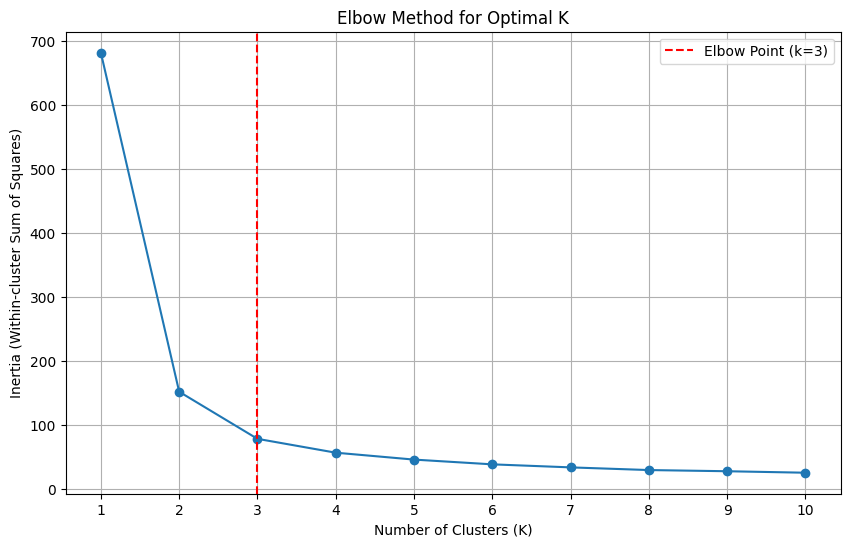

In [ ]:
## Use the Elbow Method to determine the optimal number of clusters.

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

X = df.drop(columns=['Cluster'], errors='ignore')

inertia_values = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.xticks(k_range)
plt.grid(True)

plt.axvline(x=3, color='r', linestyle='--', label='Elbow Point (k=3)')
plt.legend()
plt.show()


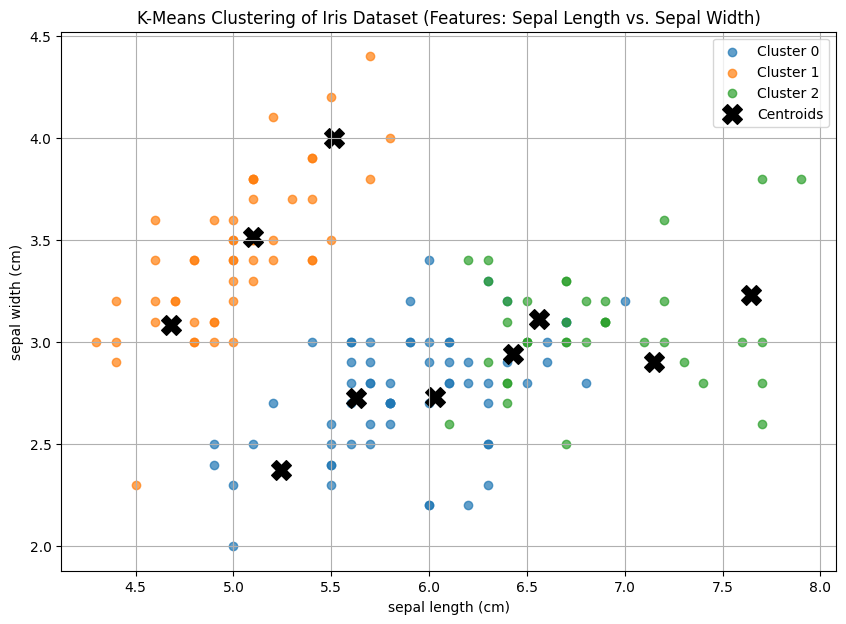

In [ ]:
## Cluster Visualization

import matplotlib.pyplot as plt

feature_x = 'sepal length (cm)'
feature_y = 'sepal width (cm)'

centroids = kmeans.cluster_centers_

plt.figure(figsize=(10, 7))


for cluster_id in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster_id]
    plt.scatter(
        cluster_data[feature_x],
        cluster_data[feature_y],
        label=f'Cluster {cluster_id}',
        alpha=0.7
    )

# centroids[:, 0] gets all values from the first feature dimension (sepal length)
# centroids[:, 1] gets all values from the second feature dimension (sepal width)
plt.scatter(
    centroids[:, df.columns.get_loc(feature_x)],
    centroids[:, df.columns.get_loc(feature_y)],
    marker='X',
    s=200,
    color='black',
    label='Centroids'
)

plt.title('K-Means Clustering of Iris Dataset (Features: Sepal Length vs. Sepal Width)')
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.legend()
plt.grid(True)
plt.show()

## Section B: Principal Component Analysis (PCA) (25)
### Task 2 – PCA & Visualization

- Apply PCA on the Iris dataset to reduce it to 2 dimensions.

- Plot the first two principal components.

- Show explained variance ratio.

- Compare clustering results on PCA-reduced data vs original data.

In [ ]:
## Apply PCA on the Iris dataset to reduce it to 2 dimensions.

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

X_features = df.drop(columns=['Cluster'], errors='ignore')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print("Standardized Features:\n")
print(pd.DataFrame(X_scaled, columns=X_features.columns).head())
print("\n")

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Principal Components:\n")
print(pd.DataFrame(X_pca, columns=['PC1', 'PC2']).head())
print("\n")

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])


if 'Cluster' in df.columns:
    pca_df['Cluster'] = df['Cluster']

print("PCA DataFrame with Cluster Assignments (first 5 rows):\n")
print(pca_df.head())

Standardized Features:

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.900681          1.019004          -1.340227         -1.315444
1          -1.143017         -0.131979          -1.340227         -1.315444
2          -1.385353          0.328414          -1.397064         -1.315444
3          -1.506521          0.098217          -1.283389         -1.315444
4          -1.021849          1.249201          -1.340227         -1.315444


Principal Components:

        PC1       PC2
0 -2.264703  0.480027
1 -2.080961 -0.674134
2 -2.364229 -0.341908
3 -2.299384 -0.597395
4 -2.389842  0.646835


PCA DataFrame with Cluster Assignments (first 5 rows):

        PC1       PC2  Cluster
0 -2.264703  0.480027        1
1 -2.080961 -0.674134        1
2 -2.364229 -0.341908        1
3 -2.299384 -0.597395        1
4 -2.389842  0.646835        1


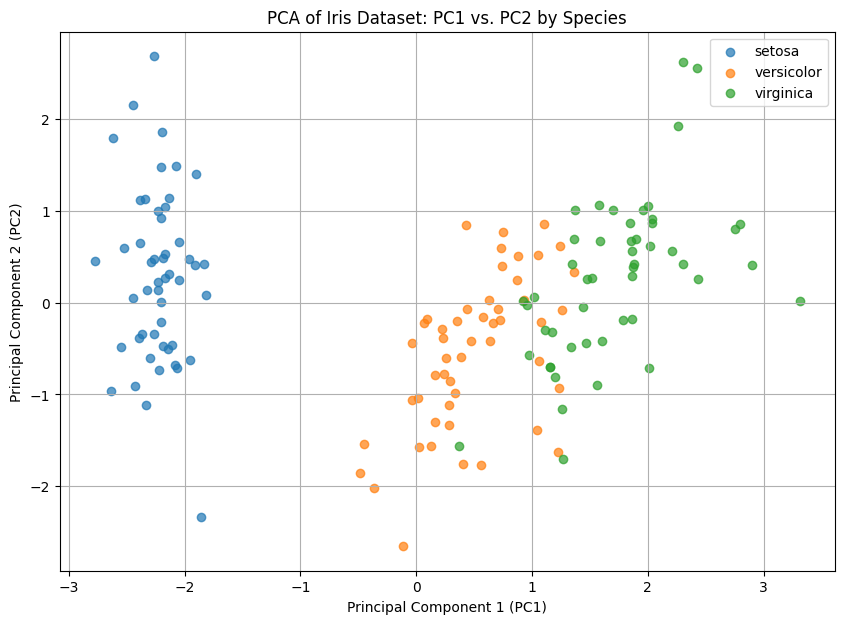

In [ ]:
## Plot the first two principal components.

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()


if 'target' not in pca_df.columns:
    pca_df['target'] = iris.target

plt.figure(figsize=(10, 7))

for species_id in sorted(pca_df['target'].unique()):
    species_data = pca_df[pca_df['target'] == species_id]
    plt.scatter(
        species_data['PC1'],
        species_data['PC2'],
        label=iris.target_names[species_id],
        alpha=0.7
    )

plt.title('PCA of Iris Dataset: PC1 vs. PC2 by Species')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
## Show explained variance ratio.

import numpy as np

explained_variance_ratio = pca.explained_variance_ratio_

print("--- Explained Variance Ratio from PCA ---")
print(f"Variance Explained by PC1: {explained_variance_ratio[0]:.4f} ({explained_variance_ratio[0]*100:.2f}%)")
print(f"Variance Explained by PC2: {explained_variance_ratio[1]:.4f} ({explained_variance_ratio[1]*100:.2f}%)")

cumulative_explained_variance = np.cumsum(explained_variance_ratio)
print(f"Cumulative Variance Explained by PC1 and PC2: {cumulative_explained_variance[1]:.4f} ({cumulative_explained_variance[1]*100:.2f}%)")

--- Explained Variance Ratio from PCA ---
Variance Explained by PC1: 0.7296 (72.96%)
Variance Explained by PC2: 0.2285 (22.85%)
Cumulative Variance Explained by PC1 and PC2: 0.9581 (95.81%)



--- K-Means Clustering on Original Iris Dataset ---

--- K-Means Clustering on PCA-Reduced Iris Dataset ---


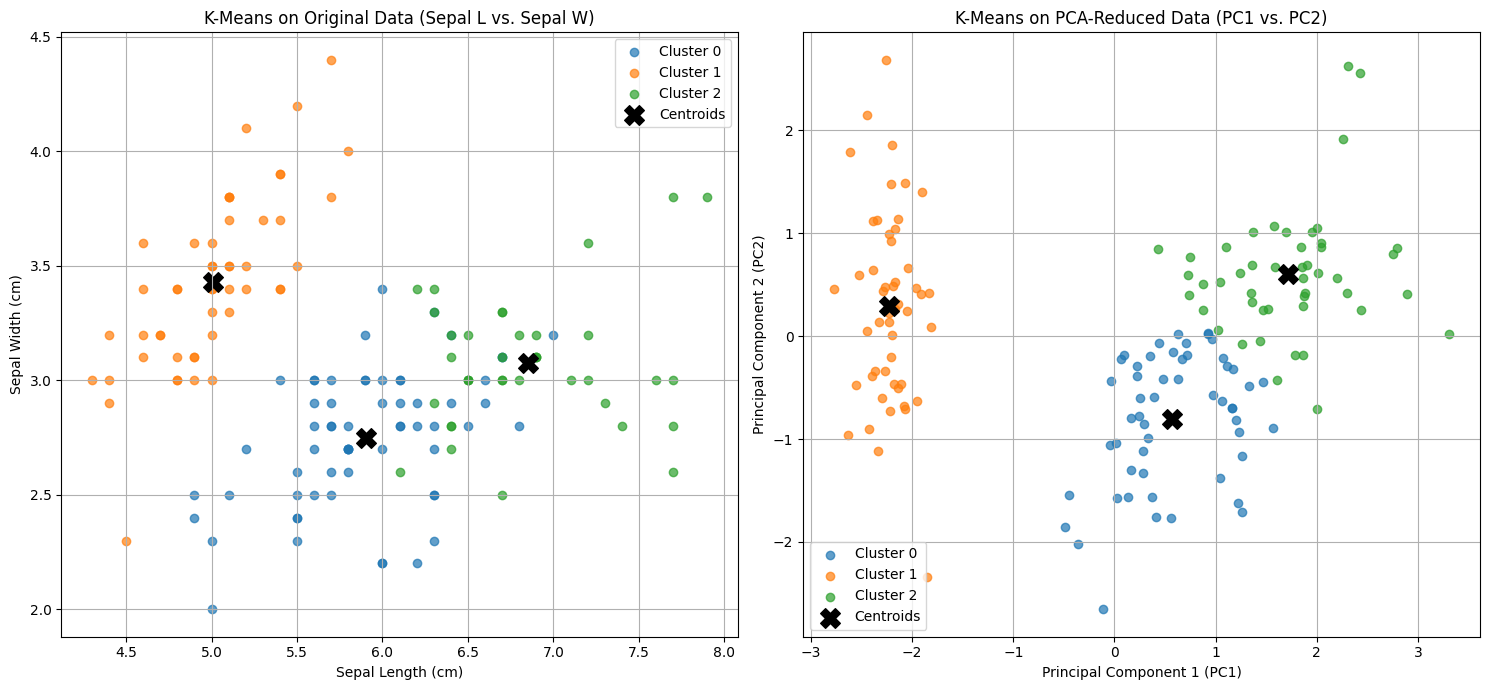

In [ ]:
## Compare clustering results on PCA-reduced data vs original data.

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df_original = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# --- K-Means on Original Iris Dataset (k=3) ---
print("\n--- K-Means Clustering on Original Iris Dataset ---")
kmeans_original = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels_original = kmeans_original.fit_predict(df_original)
df_original['KMeans_Cluster_Original'] = cluster_labels_original

print("\n--- K-Means Clustering on PCA-Reduced Iris Dataset ---")
X_pca_only = pca_df[['PC1', 'PC2']]
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels_pca = kmeans_pca.fit_predict(X_pca_only)
pca_df['KMeans_Cluster_PCA'] = cluster_labels_pca

# --- Visualizations ---

plt.figure(figsize=(15, 7))

# Plot 1: K-Means on Original Data
plt.subplot(1, 2, 1)
for cluster_id in sorted(df_original['KMeans_Cluster_Original'].unique()):
    cluster_data = df_original[df_original['KMeans_Cluster_Original'] == cluster_id]
    plt.scatter(
        cluster_data['sepal length (cm)'],
        cluster_data['sepal width (cm)'],
        label=f'Cluster {cluster_id}',
        alpha=0.7
    )
plt.scatter(
    kmeans_original.cluster_centers_[:, df_original.columns.get_loc('sepal length (cm)')],
    kmeans_original.cluster_centers_[:, df_original.columns.get_loc('sepal width (cm)')],
    marker='X', s=200, color='black', label='Centroids'
)
plt.title('K-Means on Original Data (Sepal L vs. Sepal W)')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend()
plt.grid(True)

# Plot 2: K-Means on PCA-Reduced Data (PC1 vs PC2)
plt.subplot(1, 2, 2)
for cluster_id in sorted(pca_df['KMeans_Cluster_PCA'].unique()):
    cluster_data = pca_df[pca_df['KMeans_Cluster_PCA'] == cluster_id]
    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster_id}',
        alpha=0.7
    )
plt.scatter(
    kmeans_pca.cluster_centers_[:, 0],
    kmeans_pca.cluster_centers_[:, 1],
    marker='X', s=200, color='black', label='Centroids'
)
plt.title('K-Means on PCA-Reduced Data (PC1 vs. PC2)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Section C: Hierarchical Clustering (25)
### Task 3 – Hierarchical Clustering & Dendrogram

- Apply Hierarchical Clustering on the Iris dataset.

- Draw a dendrogram.

- Compare clusters with K-Means results.

In [ ]:
## Apply Hierarchical Clustering on the Iris dataset.

from sklearn.cluster import AgglomerativeClustering

X_hierarchical = df_original.drop(columns=['KMeans_Cluster_Original'], errors='ignore')

print("--- Hierarchical Clustering (Agglomerative) Results ---")

agglomerative_clustering = AgglomerativeClustering(n_clusters=3)
cluster_labels_hierarchical = agglomerative_clustering.fit_predict(X_hierarchical)

# Add the hierarchical cluster labels to the DataFrame
df_original['Hierarchical_Cluster'] = cluster_labels_hierarchical

print("First 10 rows with Hierarchical Cluster assignments:")
print(df_original.head(10))

--- Hierarchical Clustering (Agglomerative) Results ---
First 10 rows with Hierarchical Cluster assignments:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   KMeans_Cluster_Ori

--- Dendrogram for Iris Dataset ---


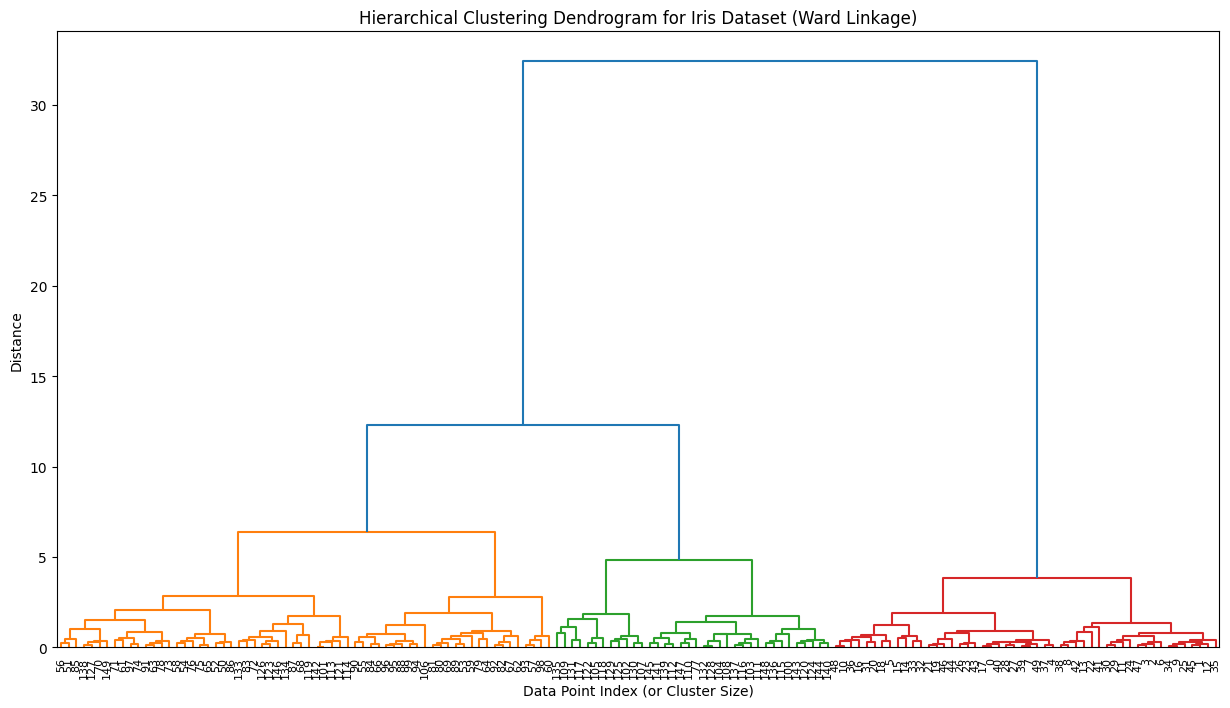

In [ ]:
## Draw a dendrogram.

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
import pandas as pd

X_dendrogram = df_original.drop(columns=['KMeans_Cluster_Original', 'Hierarchical_Cluster'], errors='ignore')

print("--- Dendrogram for Iris Dataset ---")

linked = linkage(X_dendrogram, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 8))
dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True,
    leaf_rotation=90.,
    leaf_font_size=8.,
    color_threshold=10
)
plt.title('Hierarchical Clustering Dendrogram for Iris Dataset (Ward Linkage)')
plt.xlabel('Data Point Index (or Cluster Size)')
plt.ylabel('Distance')
plt.show()

In [ ]:
## Compare clusters with K-Means results.

import pandas as pd
from sklearn.metrics import adjusted_rand_score

print("--- Comparing K-Means and Hierarchical Clustering on Iris Dataset ---")

if 'KMeans_Cluster_Original' in df_original.columns and 'Hierarchical_Cluster' in df_original.columns:
    ari_score = adjusted_rand_score(df_original['KMeans_Cluster_Original'], df_original['Hierarchical_Cluster'])
    print(f"\nAdjusted Rand Index (ARI) between K-Means and Hierarchical Clustering assignments: {ari_score:.4f}")
    print("\nCross-tabulation of Cluster Assignments:")
    print(pd.crosstab(df_original['KMeans_Cluster_Original'], df_original['Hierarchical_Cluster'],
                      rownames=['K-Means Cluster'], colnames=['Hierarchical Cluster']))

--- Comparing K-Means and Hierarchical Clustering on Iris Dataset ---

Adjusted Rand Index (ARI) between K-Means and Hierarchical Clustering assignments: 0.9611

Cross-tabulation of Cluster Assignments:
Hierarchical Cluster   0   1   2
K-Means Cluster                 
0                     62   0   0
1                      0  50   0
2                      2   0  36


## Section D: DBSCAN (25)
### Task 4 – DBSCAN Clustering

- Apply DBSCAN on the Iris dataset.

- Experiment with different values of eps and min_samples.

- Plot clusters with noise points highlighted.

- Compare DBSCAN clusters with K-Means clusters.

In [ ]:
## Apply DBSCAN on the Iris dataset.

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

print("--- DBSCAN Clustering on Iris Dataset ---")

X_dbscan = df_original.drop(columns=['KMeans_Cluster_Original', 'Hierarchical_Cluster'], errors='ignore')

scaler = StandardScaler()
X_scaled_dbscan = scaler.fit_transform(X_dbscan)

dbscan = DBSCAN(eps=0.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled_dbscan)

df_original['DBSCAN_Cluster'] = dbscan_labels

n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)

print(f"\nNumber of discovered clusters: {n_clusters_}")
print(f"Number of noise points (assigned label -1): {n_noise_}")

print("\nFirst 10 rows with DBSCAN cluster assignments:")
print(df_original.head(10))


--- DBSCAN Clustering on Iris Dataset ---

Number of discovered clusters: 2
Number of noise points (assigned label -1): 34

First 10 rows with DBSCAN cluster assignments:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1 

In [ ]:
## Experiment with different values of eps and min_samples.

import pandas as pd
from sklearn.cluster import DBSCAN
import numpy as np
from sklearn.preprocessing import StandardScaler

print("--- Experimenting with DBSCAN Parameters on Iris Dataset ---")

if 'X_scaled_dbscan' not in locals():

    X_dbscan = df_original.drop(columns=['KMeans_Cluster_Original', 'Hierarchical_Cluster', 'DBSCAN_Cluster'], errors='ignore')
    scaler = StandardScaler()
    X_scaled_dbscan = scaler.fit_transform(X_dbscan)

eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [3, 5, 7]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan_labels = dbscan.fit_predict(X_scaled_dbscan)

        n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
        n_noise = list(dbscan_labels).count(-1)

        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise_points': n_noise
        })

results_df = pd.DataFrame(results)

print("\n### DBSCAN Parameter Experiment Results")
print(results_df.to_markdown(index=False))

--- Experimenting with DBSCAN Parameters on Iris Dataset ---

### DBSCAN Parameter Experiment Results
|   eps |   min_samples |   n_clusters |   n_noise_points |
|------:|--------------:|-------------:|-----------------:|
|   0.3 |             3 |           10 |               84 |
|   0.3 |             5 |            3 |              120 |
|   0.3 |             7 |            2 |              129 |
|   0.5 |             3 |            7 |               17 |
|   0.5 |             5 |            2 |               34 |
|   0.5 |             7 |            5 |               46 |
|   0.7 |             3 |            2 |                5 |
|   0.7 |             5 |            2 |                6 |
|   0.7 |             7 |            2 |               16 |
|   1   |             3 |            2 |                1 |
|   1   |             5 |            2 |                3 |
|   1   |             7 |            2 |                3 |


--- Visualizing DBSCAN Clustering Results ---


/tmp/ipykernel_4099/2644804313.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_clusters))


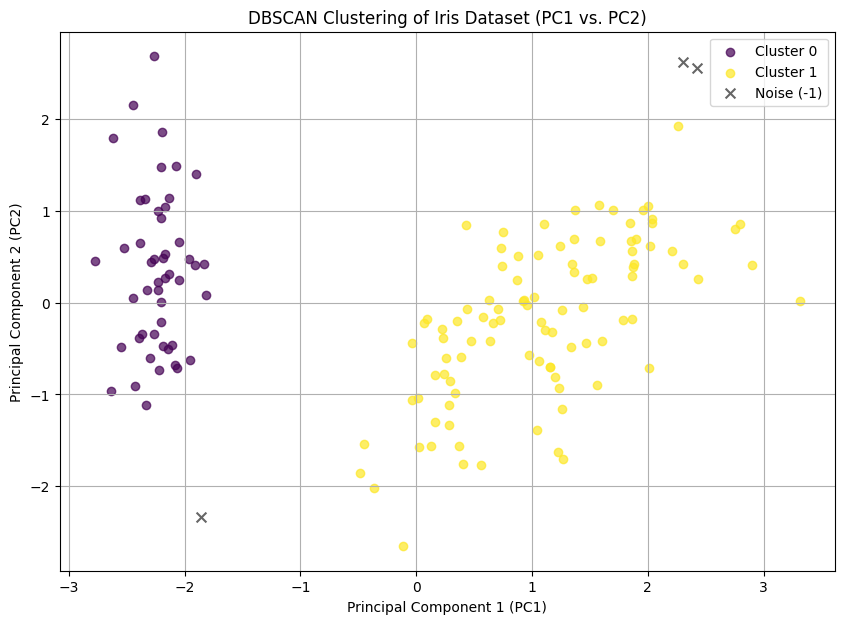

In [ ]:
## Plot clusters with noise points highlighted.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("--- Visualizing DBSCAN Clustering Results ---")
if 'X_pca' not in locals() or 'dbscan_labels' not in locals():
    print("Error: X_pca or dbscan_labels not found. Please run previous cells.")
else:
    dbscan_plot_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    dbscan_plot_df['DBSCAN_Cluster'] = dbscan_labels

    plt.figure(figsize=(10, 7))

    # Get unique cluster labels, excluding noise (-1)
    unique_clusters = np.unique(dbscan_plot_df['DBSCAN_Cluster'])
    unique_clusters = unique_clusters[unique_clusters != -1]

    colors = plt.cm.get_cmap('viridis', len(unique_clusters))

    # Plot each cluster with a distinct color
    for i, cluster_id in enumerate(unique_clusters):
        cluster_data = dbscan_plot_df[dbscan_plot_df['DBSCAN_Cluster'] == cluster_id]
        plt.scatter(
            cluster_data['PC1'],
            cluster_data['PC2'],
            color=colors(i),
            label=f'Cluster {cluster_id}',
            alpha=0.7
        )

    # Highlight noise points in black
    noise_points = dbscan_plot_df[dbscan_plot_df['DBSCAN_Cluster'] == -1]
    if not noise_points.empty:
        plt.scatter(
            noise_points['PC1'],
            noise_points['PC2'],
            color='black',
            label='Noise (-1)',
            marker='x',
            s=50,
            alpha=0.6
        )

    plt.title('DBSCAN Clustering of Iris Dataset (PC1 vs. PC2)')
    plt.xlabel('Principal Component 1 (PC1)')
    plt.ylabel('Principal Component 2 (PC2)')
    plt.legend()
    plt.grid(True)
    plt.show()

## Compare DBSCAN clusters with K-Means clusters.



| Feature                                | K-Means                                                           | DBSCAN                                                                                          |
| -------------------------------------- | ----------------------------------------------------------------- | ----------------------------------------------------------------------------------------------- |
| **How it creates groups**              | Places a center point (centroid) and groups flowers around it.    | Looks for areas where many flowers are close together.                                          |
| **Outliers (unusual data)**            | Every flower must belong to a group, even if it doesn't fit well. | Can leave unusual flowers as **noise** instead of forcing them into a group.                    |
| **Cluster shape**                      | Works best when groups are round or circular.                     | Can find groups of any shape.                                                                   |
| **Need to choose number of clusters?** | Yes. We must tell it how many groups (`k`) we want.               | No. It finds the number of groups automatically based on density.                               |
| **Easy to understand?**                | Yes, very simple and beginner-friendly.                           | Slightly harder because we need to tune `eps` and `min_samples`.                                |
| **Result on Iris dataset**             | Found 3 clusters easily, matching the 3 flower species.           | Initially found 2 clusters and some noise points. After tuning parameters, it found 3 clusters. |
